In [ ]:
import pathlib
import string
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from notebook_init_utils import init_notebook

root_dir, in_notebook = init_notebook()
warnings.filterwarnings("ignore")  # Ignore all warnings
warnings.simplefilter("ignore")  # Additional suppression method

output_path = pathlib.Path(
    root_dir,
    "4.linear_modeling/results/well_manhattan_distance/well_manhattan_distance.csv",
)
platemap_figure_path = pathlib.Path(
    root_dir,
    "4.linear_modeling/results/well_manhattan_distance/well_manhattan_distance_platemap.png",
)
output_path.parent.mkdir(parents=True, exist_ok=True)

In [2]:
# 96-well plate layout: rows A-H (1-8), columns 1-12
plate_rows = list(string.ascii_uppercase[:8])
plate_columns = list(range(1, 13))

wells_dict = {
    "well_row": [],
    "well_column": [],
    "Metadata_Experiment_Well": [],
    "row_index": [],
    "column_index": [],
}
for row in plate_rows:
    row_index = plate_rows.index(row) + 1
    for column in plate_columns:
        wells_dict["well_row"].append(row)
        wells_dict["well_column"].append(column)
        wells_dict["Metadata_Experiment_Well"].append(f"{row}{column}")
        wells_dict["row_index"].append(row_index)
        wells_dict["column_index"].append(column)

wells_df = pd.DataFrame(wells_dict)

In [3]:
# the center of a 96-well plate falls between rows D/E and columns 6/7
center_row_index = (1 + len(plate_rows)) / 2
center_column_index = (1 + len(plate_columns)) / 2

wells_df["manhattan_distance_from_center"] = (
    wells_df["row_index"] - center_row_index
).abs() + (wells_df["column_index"] - center_column_index).abs()

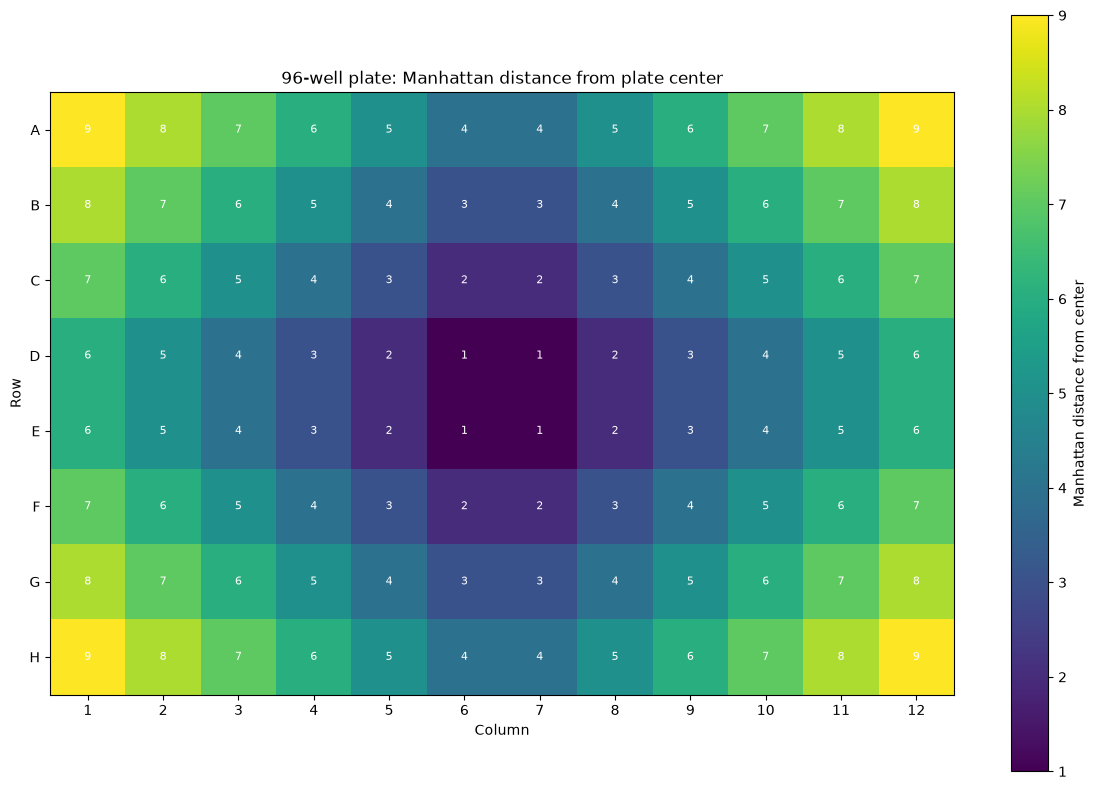

In [4]:
# plot the platemap as a grid heatmap of the Manhattan distance from center
distance_grid = wells_df.pivot(
    index="well_row", columns="well_column", values="manhattan_distance_from_center"
).loc[plate_rows, plate_columns]

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(distance_grid.values, cmap="viridis")

ax.set_xticks(np.arange(len(plate_columns)))
ax.set_xticklabels(plate_columns)
ax.set_yticks(np.arange(len(plate_rows)))
ax.set_yticklabels(plate_rows)
ax.set_xlabel("Column")
ax.set_ylabel("Row")
ax.set_title("96-well plate: Manhattan distance from plate center")

for i in range(len(plate_rows)):
    for j in range(len(plate_columns)):
        ax.text(
            j,
            i,
            f"{distance_grid.values[i, j]:g}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
        )

fig.colorbar(im, ax=ax, label="Manhattan distance from center")
fig.tight_layout()
fig.savefig(platemap_figure_path, dpi=600)
plt.show()

In [ ]:
wells_df.drop(
    columns=["well_row", "well_column", "row_index", "column_index"], inplace=True
)
wells_df.to_csv(output_path, index=False)
wells_df.head()